In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy

from scipy.stats import linregress

from scipy.optimize import curve_fit

In [14]:

# POINT VERSION (for equations)

#fIRST DERIVTAIVE
def f_prime_forward_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x + h) - f(x)) / h
    else: # high order
        slope = (-f(x + 2*h) + 4*f(x + h) - 3*f(x)) / (2*h)
    return slope, [slope]
def f_prime_backward_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x) - f(x - h)) / h
    else: # high order
        slope = (3*f(x) - 4*f(x - h) + f(x - 2*h)) / (2*h)
    return slope, [slope]
def f_prime_central_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x + h) - f(x - h)) / (2*h)
    else: # high order
        slope = (-f(x + 2*h) + 8*f(x + h) - 8*f(x - h) + f(x - 2*h)) / (12*h)
    return slope, [slope]

#SECOND DERIVATIVE

def f_double_prime_forward_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x + 2*h) - 2*f(x + h) + f(x)) / (h**2)
    else: # high order
        slope = (-f(x + 3*h) + 4*f(x + 2*h) - 5*f(x + h) + 2*f(x)) / (h**2)
    return slope, [slope]
def f_double_prime_backward_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x) - 2*f(x - h) + f(x - 2*h)) / (h**2)
    else: # high order
        slope = (2*f(x) - 5*f(x - h) + 4*f(x - 2*h) - f(x - 3*h)) / (h**2)
    return slope, [slope]
def f_double_prime_central_point(f, x, h, order='low'):
    if order == 'low':
        slope = (f(x + h) - 2*f(x) + f(x - h)) / (h**2)
    else: # high order
        slope = (-f(x + 2*h) + 16*f(x + h) - 30*f(x) + 16*f(x - h) - f(x - 2*h)) / (12*h**2)
    return slope, [slope]


# LIST VERSION (for data)

#first derivative
def f_prime_forward_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    # Stop early enough to look ahead
    limit = 2 * jump if order == 'high' else jump
    for i in range(len(y_list) - limit):
        if order == 'low':
            s = (y_list[i + jump] - y_list[i]) / h
        else:
            s = (-y_list[i + 2*jump] + 4*y_list[i + jump] - 3*y_list[i]) / (2*h)
        slopes.append(s)
    return slopes[-1], slopes
def f_prime_backward_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    # Start late enough to look backward
    start_index = 2 * jump if order == 'high' else jump
    for i in range(start_index, len(y_list)):
        if order == 'low':
            s = (y_list[i] - y_list[i - jump]) / h
        else:
            s = (3*y_list[i] - 4*y_list[i - jump] + y_list[i - 2*jump]) / (2*h)
        slopes.append(s)
    return (slopes[-1] if slopes else 0), slopes
def f_prime_central_list(y_list, h, GAP, order='low'):

    jump = int(round(h / GAP))
    slopes = []
    limit = 2 * jump if order == 'high' else jump
    for i in range(limit, len(y_list) - limit):
        if order == 'low':
            s = (y_list[i + jump] - y_list[i - jump]) / (2*h)
        else:
            s = (-y_list[i + 2*jump] + 8*y_list[i + jump] - 8*y_list[i - jump] + y_list[i - 2*jump]) / (12*h)
        slopes.append(s)
    return slopes[-1], slopes

#second derivative

def f_double_prime_forward_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    limit = 3 * jump if order == 'high' else 2 * jump
    for i in range(len(y_list) - limit):
        if order == 'low':
            s = (y_list[i + 2*jump] - 2*y_list[i + jump] + y_list[i]) / (h**2)
        else:
            s = (-y_list[i + 3*jump] + 4*y_list[i + 2*jump] - 5*y_list[i + jump] + 2*y_list[i]) / (h**2)
        slopes.append(s)
    return slopes[-1], slopes
def f_double_prime_backward_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    # High order needs 4 points total (i, i-1, i-2, i-3), so start at 3*jump
    start_index = 3 * jump if order == 'high' else 2 * jump
    for i in range(start_index, len(y_list)):
        if order == 'low':
            s = (y_list[i] - 2*y_list[i - jump] + y_list[i - 2*jump]) / (h**2)
        else:
            s = (2*y_list[i] - 5*y_list[i - jump] + 4*y_list[i - 2*jump] - y_list[i - 3*jump]) / (h**2)
        slopes.append(s)
    return (slopes[-1] if slopes else 0), slopes
def f_double_prime_central_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    limit = 2 * jump if order == 'high' else jump
    for i in range(limit, len(y_list) - limit):
        if order == 'low':
            s = (y_list[i + jump] - 2*y_list[i] + y_list[i - jump]) / (h**2)
        else:
            s = (-y_list[i + 2*jump] + 16*y_list[i + jump] - 30*y_list[i] + 16*y_list[i - jump] - y_list[i - 2*jump]) / (12*h**2)
        slopes.append(s)
    return slopes[-1], slopes




In [ ]:
def true_value(true,appx):
    return np.abs(true-appx)

def fractional_true_value(true,appx):
    return np.abs(((true-appx) / (true)))

def percent_fractional_true_value(true,appx):
    return np.abs(((true-appx) / (true)) * 100)

def appx_value(current,previous):
    return np.abs(current - previous)

#the previous but in a list version

def true_absolute_err(true, list_appx):
    TA_err = []
    for i in range(len(list_appx)):
        err = np.abs(true - list_appx[i])
        TA_err.append(err)
    return TA_err

#OR, if it's an array, can just do
#bisect_tpre = np.abs(estimated_root_bisect-root_true)/root_true * 100


def true_relative_err(true, list_appx):

    TR = []          
    for i in range(len(list_appx)):
        rel_err = list_appx[i] / true
        TR.append(rel_err)
    return(TR)



def root_falseposition(f, xl, xu, tol, maxiter=100, plot_err=False):
#false position works through the assumption that x_root is closer to a. 
#however, is sensitive to curves/may diverge. If curves are one sided than it may not work
#instead of picking a middle point, it draws a line between f(a) and f(B)

    if f(xl)*f(xu) > 0:
       print("No roots identified in domain [{:}, {:}]".format(xl, xu))
       return()

    count = 0
    estimated_root = []
    xr = xu
    while True:
        count += 1
        xrold = xr
        xr = xu - ( (f(xu)*(xl-xu)) / (f(xl)-f(xu)) )     # Only line modified from bisection method.  New intermediate point.
        estimated_root.append(xr)
        if xr != 0:
            err = np.abs((xr - xrold) / xr) * 100         # Approximate percent relative error.

        test = f(xl) * f(xr)
        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            err = 0

        if err < tol or count >= maxiter: break

    estimated_root = np.array(estimated_root)
    if plot_err == True:
        def plot_error(x, y1, y2):
            fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
            ax.semilogy(x[:-1], y1[:-1], label="True")
            ax.semilogy(x[1:], y2, label='Approximate')
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Percent relative error (%)')
            ax.set_xticks(range(1, len(x)+1))
            ax.legend()

        root = xr
        true_rel_error = np.abs((estimated_root - root) / root) * 100
        approx_rel_error = np.abs((estimated_root[1:] - estimated_root[:-1]) / estimated_root[1:]) * 100
        plot_error(np.arange(1, len(estimated_root) + 1), true_rel_error, approx_rel_error)

    return(xr, estimated_root)

def root_bisection(f, xl, xu, tol, maxiter=100):

    #inputs our function from range xlower (xl) to xupper

    #this checks an inputted change to see if there is a sign change
    if f(xl)*f(xu) > 0:
       print("No roots identified in domain [{:}, {:}]".format(xl, xu))
       return()
       
    count = 0
    #xr is the current guess
    xr = xu

    while True:
        count += 1
        xrold = xr

        #sets current guess to in between upper and lower limits
        xr = (xl + xu) / 2
        if xr != 0:
            err = np.abs((xr - xrold) / xr) * 100           # Approximate percent relative error.
        
        test = f(xl) * f(xr)
        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else: 
            err = 0
           
        if err < tol or count >= maxiter: break  

#example useage

# root_bisection(f, 0, 2, 1e-4)


    return(xr)

#convergence is guaranteed for bisection, but slower than false position

def root_bisection_plot(f, xl, xu, tol, maxiter=100, plot_err=False):



    
    
    if f(xl)*f(xu) > 0:
       print("No roots identified in domain [{:}, {:}]".format(xl, xu))
       return()
       
    count = 0
    estimated_root = []
    xr = xu
    while True:
        count += 1
        xrold = xr
        xr = (xl + xu) / 2
        estimated_root.append(xr)
        if xr != 0:
            err = np.abs((xr - xrold) / xr) * 100           # Approximate percent relative error.
        
        test = f(xl) * f(xr)
        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else: 
            err = 0
           
        if err < tol or count >= maxiter: break  
            
    estimated_root = np.array(estimated_root)
    if plot_err == True:
        def plot_error(x, y1, y2):  
            fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
            ax.semilogy(x[:-1], y1[:-1], label="True")
            ax.semilogy(x[1:], y2, label='Approximate')
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Percent relative error (%)')
            ax.set_xticks(range(1, len(x)+1))
            ax.legend()

        root = xr
        true_rel_error = np.abs((estimated_root - root) / root) * 100
        approx_rel_error = np.abs((estimated_root[1:] - estimated_root[:-1]) / estimated_root[1:]) * 100
        plot_error(np.arange(1, len(estimated_root) + 1), true_rel_error, approx_rel_error)   
        
#example usage
# (root, estimated_roots) = root_bisection(f, 0, 2, 1e-3, plot_err=True)
# print(root)
# print(estimated_roots)



    return(xr, estimated_root)

def roots_bisect_multipleroots(f, xl, xu, tol, maxiter=100, subintervals=100, plot_results=False):
    #splits original range into x subintervals


#multiple roots works by dividing one given interval into [subintervals] subintervals. 
#now, in one range, there's 100 different ranges, where the root finding method is called on all of them. 



    #f is our original function
    intervals = np.linspace(xl, xu, subintervals+1)
    roots = []
    #this for loop indexes into EACH subinterval, but doesn't go over the range of it
    for i in range(subintervals):
        #now, it's indexing in between the range of each subinterval
        if f(intervals[i]) * f(intervals[i+1]) < 0:
            #root_bisection could be swapped out with your root finding method of choice
            root = root_bisection(f, intervals[i], intervals[i+1], tol, maxiter)
            roots.append(root[0])

    roots = np.array(roots)
    if plot_results == True:
        x = np.linspace(xl, xu, 1000)
        plt.figure(figsize=(6, 4), dpi=150)
        plt.plot(x, f(x), 'b-')
        plt.plot(roots, np.zeros_like(f(roots)), 'ro')
        plt.plot(x, np.zeros_like(f(x)), 'k-')
        plt.xlim(xl,xu)
        plt.xlabel("$x$")
        plt.ylabel("$f(x)$")
            


#example usage
# roots_bisect_multipleroots(f, -10, 0, 1e-4, subintervals=1000, plot_results=True)
    return roots

# bisect_tpre = np.abs(estimated_root_bisect-root_true)/root_true * 100
# false_position_tpre = np.abs(estimated_root_fp-root_true)/root_true *100



def newton_raphson(function,function_prime,max_iter, guess):

    #newton raphson works by! we have a guess x, and a function f(x) and it's derivative f'(x)
#we take the tangent line (slope) at x at the function f(x), and when this tangent line hits zero, then that's our next guess. 
# Newton might shoot off to infinity if it hits a flat spot (f'x)≈0).
#or osicliations it could over estimate or can miss a zero
    iteration = 0 
    guess_every_iter = []
    while iteration < max_iter:
        guess_old = guess
        iteration += 1
        guess = guess_old - (function(guess_old) / function_prime(guess_old))
        guess_every_iter.append(guess)

    return guess, guess_every_iter
nr_tpre = np.abs(estimated_root_nr-root_true)/root_true * 100

def root_newton(f, fprime, guess, lowerlimit, upperlimit, tol=1e-100, maxiter=15):
  iteration = 0
  guess_every_iter = [guess]

  while True:
        iteration += 1
        guess_old = guess
        guess = guess_old - ( f(guess_old) / fprime(guess_old) )
        guess_every_iter.append(guess)

        if guess < lowerlimit or guess > upperlimit:
          raise Exception(f"Unphysical guess '{guess}' encountered.")

        err = abs((guess-guess_old)/guess) * 100          # Approximate percent relative error.
        if err < tol or iteration >= maxiter: break

  guess_every_iter = np.array(guess_every_iter)
  return guess, guess_every_iter

def newton_raphson_secant(function,max_iter, initial_guess_one,initial_guess_two):

# Secant might jump wildly across the graph if the two points produce a nearly horizontal line.


#newton raphson secant is when you don't know the derivative, so you use backwards 
#finite difference method to approximate derivative

#in this case, we can't find the derivative, so we take the line between f(guess one() and f(guess two)

    x0 = initial_guess_one
    x1 = initial_guess_two
    iteration = 0 
    guess_every_iter = []
    while iteration < max_iter:
        iteration +=1 
        guess = x1 - function(x1) * ((x1-x0)/(function(x1) - function(x0)))

        #now, our current guess becomes our "x1" and our old x1 becomes our x0?
        x1 = guess
        x0=x1
        guess_every_iter.append(guess)

    return guess, guess_every_iter

def NOTES():
    #note, these are general equations. they don't work on some stuff. you need to feed in a 
#range of x that is a list, and then index into that list. these are just the raw functions. 
#these functions are modified so you input a range of x values as your x. 
#it then indexes over each x value in that range (based on the length)
#and the "x value" passed into the function is the value of that i index +/- jump.


    return()

#IN ADDITION, STEP can be calculated as y_array[i+1] - y_array[i]
#or y_array[i+2] - y_array[i+1]

#step calculation formula
#this calculates each "step" in between each value in a list
def step_calc(input_list):
    list_of_steps = []
    for i in range(len(input_list)-1):
        step = input_list[i+1] - input_list
        list_of_steps.append(step)
    
    return list_of_steps

#FIRST DERIVATIVE 

def forward_1st_order(f, x_list, h, GAP):
    #GAP is the numerical difference between each value of a list. 
    #for example, if the 0th value is 50meters, and 1st value is 100m, then GAP IS 50.
    

    #jump normalizes how much you're increasing your INDEXING by.
    # if you want to move by a step size of 50 meters, you just want to index by moving to the next index
    # so your jump would be 1 (because 50/50 = 1) 
 
    #f is function
    #h is step
    #x is x value
    slopes = []
    jump = int(round(h / GAP))
    for i in range(len(x_list) - jump):
        slope = (f(x_list[i + jump]) - f(x_list[i])) / h
        slopes.append(slope)
    return slopes

#this is for multiple h values
def forward_1st_order_multi_h(f, x_list, h_list, GAP):
    all_slopes = []
    
    for h in h_list:
        slopes = []
        # Calculate the index jump for this specific h
        jump = int(round(h / GAP))
        
        # Iterate until the end of the list minus the jump to stay in bounds
        for i in range(len(x_list) - jump):
            # Standard 1st order forward difference formula
            slope = (f(x_list[i + jump]) - f(x_list[i])) / h
            slopes.append(slope)
        
        # Add this specific list of slopes to our master list
        all_slopes.append(slopes)
        
    return all_slopes

def forward_2nd_order(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(len(x_list) - 2 * jump):
        slope = (-f(x_list[i + 2*jump]) + 4*f(x_list[i + jump]) - 3*f(x_list[i])) / (2 * h)
        slopes.append(slope)
    return slopes

def backward_1st_order(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(jump, len(x_list)):
        slope = (f(x_list[i]) - f(x_list[i - jump])) / h
        slopes.append(slope)
    return slopes

def backward_2nd_order(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(2 * jump, len(x_list)):
        slope = (3*f(x_list[i]) - 4*f(x_list[i - jump]) + f(x_list[i - 2*jump])) / (2 * h)
        slopes.append(slope)
    return slopes

def central_2nd_order(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(jump, len(x_list) - jump):
        slope = (f(x_list[i + jump]) - f(x_list[i - jump])) / (2 * h)
        slopes.append(slope)
    return slopes

def fourth_order_CFD(f,x_list,h,GAP):
    jump = int(h / GAP)
    slopes = []
    #because central finite difference, we subtract the first two and last two points
    for i in range(2 * jump, len(x_list) - (2 * jump)):
        slope = (-f(x_list[i+(2*jump)]) + 8*f(x_list[i+jump]) - 8*f(x_list[i-jump]) + f(x_list[i-(2*jump)])) / (12*h)
        slopes.append(slope)

    return slope, slopes

#SECOND DERIVATIVE

def forward_1st_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(len(x_list) - 2 * jump):
        slope = (f(x_list[i + 2*jump]) - 2*f(x_list[i + jump]) + f(x_list[i])) / (h**2)
        slopes.append(slope)
    return slopes

def forward_2nd_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(len(x_list) - 3 * jump):
        slope = (-f(x_list[i+3*jump]) + 4*f(x_list[i+2*jump]) - 5*f(x_list[i+jump]) + 2*f(x_list[i])) / (h**2)
        slopes.append(slope)
    return slopes

def backward_1st_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(2 * jump, len(x_list)):
        slope = (f(x_list[i]) - 2*f(x_list[i - jump]) + f(x_list[i - 2*jump])) / (h**2)
        slopes.append(slope)
    return slopes

def backward_2nd_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(3 * jump, len(x_list)):
        slope = (2*f(x_list[i]) - 5*f(x_list[i-jump]) + 4*f(x_list[i-2*jump]) - f(x_list[i-3*jump])) / (h**2)
        slopes.append(slope)
    return slopes

def central_2nd_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(jump, len(x_list) - jump):
        slope = (f(x_list[i + jump]) - 2*f(x_list[i]) + f(x_list[i - jump])) / (h**2)
        slopes.append(slope)
    return slopes

def central_4th_order_2nd_deriv(f, x_list, h, GAP):
    jump = int(round(h / GAP))
    slopes = []
    for i in range(2 * jump, len(x_list) - 2 * jump):
        slope = (-f(x_list[i+2*jump]) + 16*f(x_list[i+jump]) - 30*f(x_list[i]) + 16*f(x_list[i-jump]) - f(x_list[i-2*jump])) / (12 * h**2)
        slopes.append(slope)
    return slopes





 def V_desired(guess_h, V_fill):
        return V(guess_h)-V_fill

#an equvilanet to this is to use the lambda function

def depth_solve_bisect(V_fill, lower, upper, n):
    return (root_bisection(lambda h: V(h) - V_fill, lower, upper, 1e-100, n))



def least_squares_regress(x_array,y_array):
    n=len(x_array)
    sum_x_y=0
    sum_x = 0
    sum_y = 0
    sum_x_x = 0
    sum_y_y=0

    for i in range(n):
        sum_x_y +=x_array[i]*y_array[i]
        sum_x_x += x_array[i]**2
        sum_y +=y_array[i]
        sum_x += x_array[i]
        sum_y_y += y_array[i]**2

    a1 = ((n * sum_x_y) - (sum_y*sum_x)) / ((n*sum_x_x) - (sum_x**2))
    #y_bar and x_bar is expected value or mean
    y_bar = (sum_y) / n
    x_bar = sum_x / n 

    a0 = y_bar - a1*x_bar
    r = 0 
    r = ((n*sum_x_y) - (sum_x*sum_y) )/ (np.sqrt((n*sum_x_x) - (sum_x**2)) * np.sqrt((n*sum_y_y) - (sum_y**2)) )   

    slope = a1
    intercept = a0
    correlation_coefficient = r
    #r is the correlation coefficient, r^2 is the coefficient of determination
    #the better the fit, the closer the r^2 value is to one. 
    return slope, intercept, correlation_coefficient

def sum_square_resid(y_observed,y_appx,n):
    #sum of the squares of residiuals
    #y_observed is either true or observed value
    #n is sample size
    
 #n = len(y_observed)

    #represents average spread of our estimates around the regression line
    for i in range(n):
        sr += ((y_observed - y_appx)**2)

    return sr

def std_err_of_estimate(y_observed,y_appx,n):
    #this is for first order polynomial
    sr = sum_square_resid(y_observed,y_appx,n)
    s_y_x = np.sqrt(sr / (n-2)) 
    return s_y_x

def regression_std_eror(y_observed,y_appx,n, m):
    #this is for mth order polynomial

    #standard error of the estimate.
    # quantifies the spread around the regression line 

    #contrasts original standard deviation sy that quantifi ed the spread around the mean

    #n is sample size
    #m is order of the polynomial we're fitting 

    sr = sum_square_resid(y_observed,y_appx,n) 
    s_y_x = np.sqrt(sr / (n-(m+1)))

    return s_y_x





IndentationError: unindent does not match any outer indentation level (<string>, line 463)

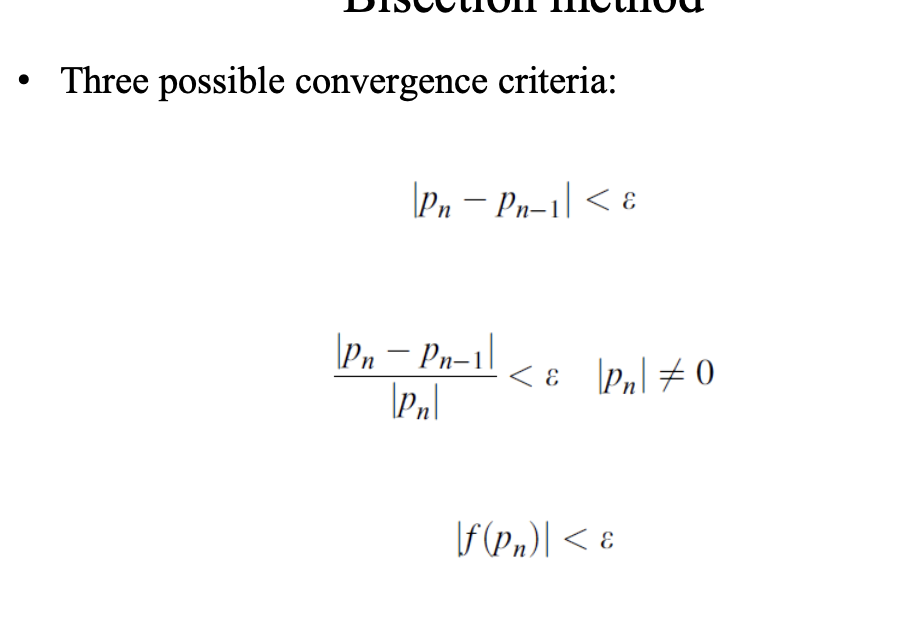

Fixed point iteration is first order error.
newton raphson is second order error, better.

In [15]:
stepx = np.linspace(0,10,21)
print(stepx)

for i in stepx:
    print(i)


dict = {"1":"a", "2":2}

print(dict["1"])

print(dict["2"])

dict["2"] +=1

print(dict["2"])

#SLCIING
#               0 1 2 3 4 5 6 
example_list = [1,2,3,4,5,6,7]
#              -7 -6 -5 -4 -3 -2 -1
print(example_list[2:])
[3, 4, 5, 6, 7]
print(example_list[:2])
[1, 2]
print(example_list[-2:])
[6, 7]
print(example_list[:-2])
[1, 2, 3, 4, 5]
print(example_list[:])
[1, 2, 3, 4, 5, 6, 7]
print(example_list[-6:3])
[2, 3]
print(example_list[-5:0])
[]

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]
0.0
0.5
1.0
1.5
2.0
2.5
3.0
3.5
4.0
4.5
5.0
5.5
6.0
6.5
7.0
7.5
8.0
8.5
9.0
9.5
10.0
a
2
3
[3, 4, 5, 6, 7]
[1, 2]
[6, 7]
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5, 6, 7]
[2, 3]
[]


[]

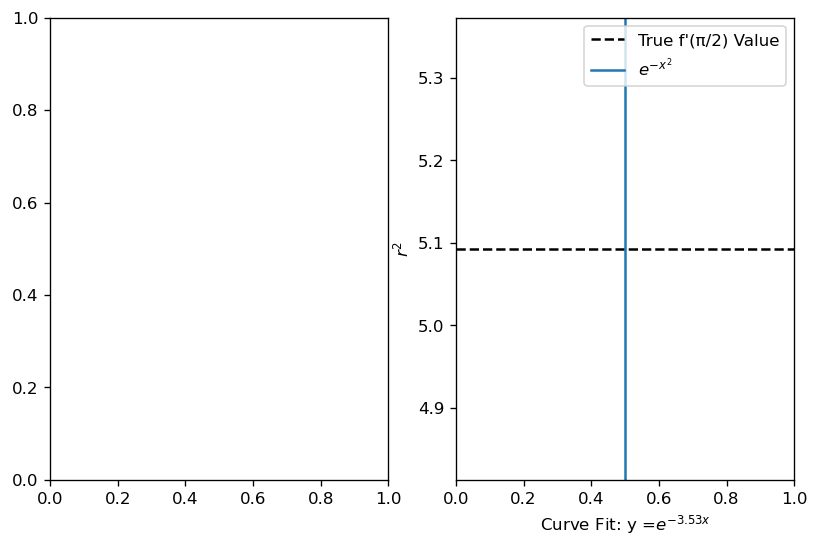

In [152]:
#when creating plots, 

plt.figure(figsize=(8, 5), dpi=120)

#row, column, position
plt.subplot(121)

plt.subplot(122)
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.axvline(x=0.5,label = "$e^{{-x}^2}$")
variable = 3.5324
plt.xlabel(f"Curve Fit: y =$e^{{-{variable:.3g} x}}$")
plt.ylabel(f"$r^{2}$")
plt.legend()

Text(0.5, 0, 'x label')

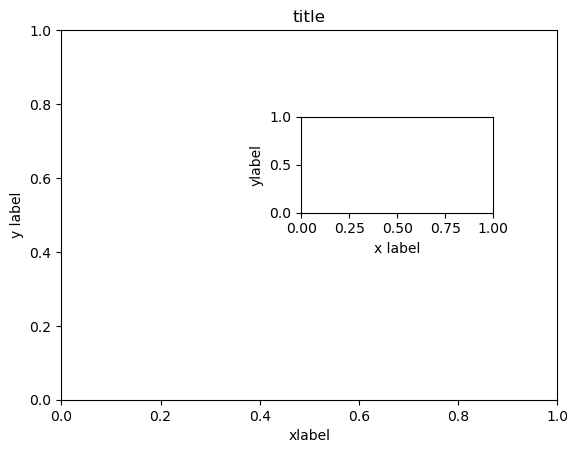

In [37]:
#INSET PLOT

#creates first subplot
plt.subplot(111)

plt.ylabel("y label")
plt.xlabel("xlabel")
plt.title("title")

#inset plot

#x position, y position, x_width, y_width

inset = plt.axes([0.5,0.5,0.3,0.2])
inset.semilogx
inset.semilogy
inset.set_ylabel("ylabel")
inset.set_xlabel("x label")

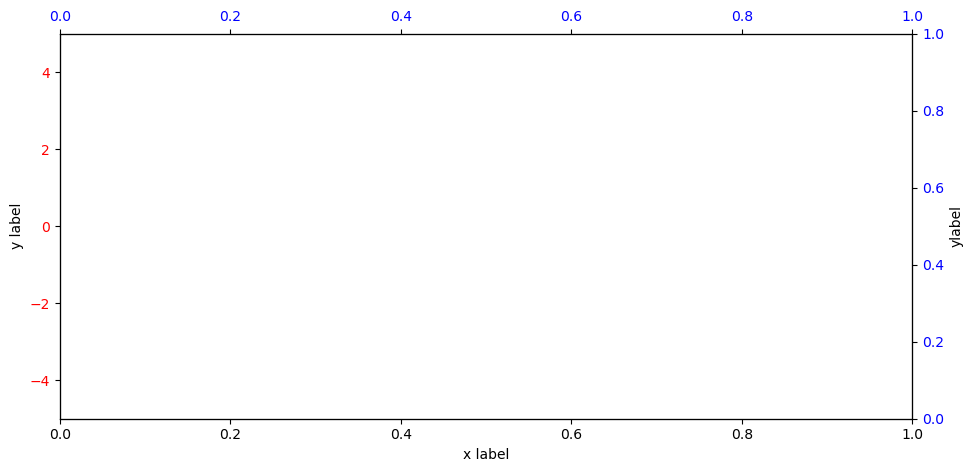

In [65]:
#dual axes
fig,ax1 = plt.subplots(figsize = (11,5))
ax1.set_ylabel("y label")
ax1.set_xlabel("x label")
ax1.tick_params(labelcolor="red", axis="y")
ax1.set_ylim(-1,2)

ax2=ax1.twiny()
ax2.set_ylabel("ylabel")
ax2.tick_params(labelcolor="blue")
ax2.set_ylim(-5,5)

ax2=ax1.twinx()
ax2.set_ylabel("ylabel")
ax2.tick_params(labelcolor="blue")



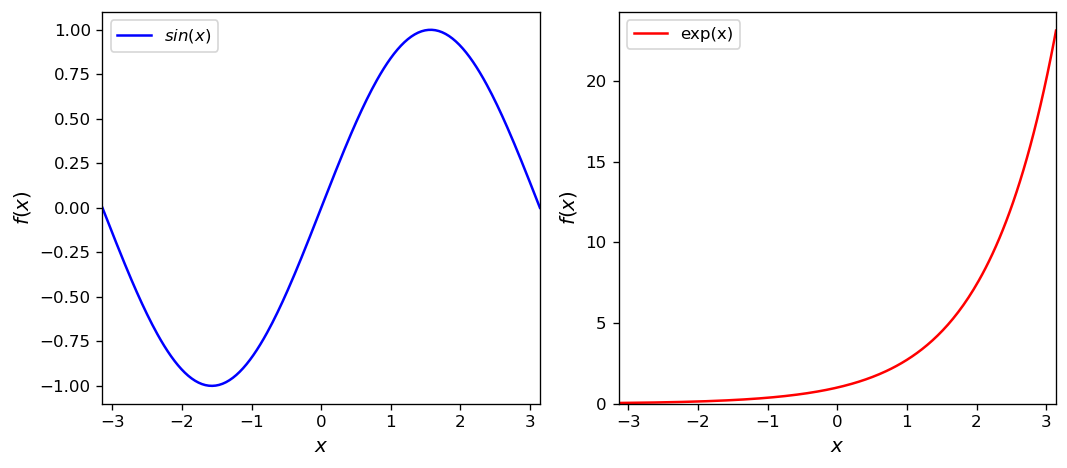

In [97]:
X = np.linspace(-np.pi, np.pi, 256, endpoint=True)

fig, (ax1, ax2) = plt.subplots(figsize = (9, 4), ncols = 2, nrows = 1, dpi=120)
ax1.plot(X, np.sin(X), "b-", label = "$sin(x)$")
ax1.set_xlabel("$x$", fontsize=12)
ax1.set_ylabel("$f(x)$", fontsize=12)
ax1.set_xlim(-np.pi, np.pi)
ax1.legend()

ax2.plot(X, np.exp(X), "r-", label = "exp(x)")
ax2.set_xlabel("$x$", fontsize=12)
ax2.set_ylabel("$f(x)$", fontsize=12)
ax2.set_xlim(-np.pi, np.pi)
ax2.set_ylim(0,)
ax2.legend(loc='upper left')
plt.tight_layout()

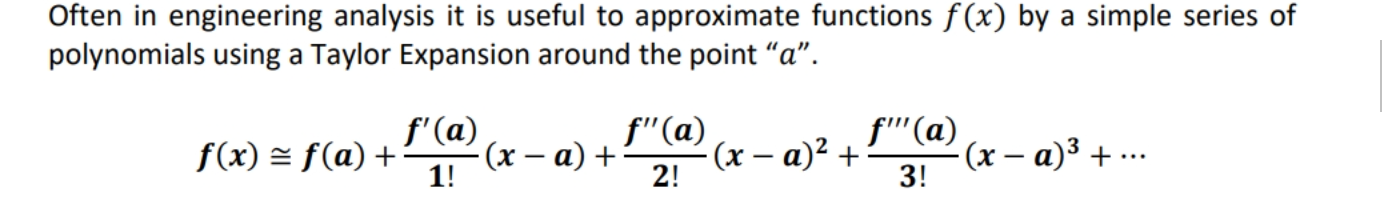

In [ ]:
#TAYLOR SERIES APPROXIMATIONS
import math
#first step: define your original function
def g(x):
    return np.sin(x) + np.cos(3*x)

#calculates all of the derivatives based on the nth order
def g_deriv(x, n):
    if n % 4 == 0 :
        return np.sin(x) + 3**n*np.cos(3*x)
    elif n % 4 == 1:
        return np.cos(x) - 3**n*np.sin(3*x)
    elif n % 4 == 2 :
        return -np.sin(x) - 3**n*np.cos(3*x)
    elif n%4 == 3:
        return -np.cos(x) + 3**n*np.sin(3*x)
    
def taylor_g(x, a, nth_order):
    #a is the center value
    #x is a linspace or a list
    #plug in n, whatever order you wat
    appx = 0
    for i in range(nth_order+1):
        appx += ((g_deriv(a,i))/math.factorial(i))*((x-a)**i)
    return appx



tol = 0.1        # target true percent relative error tolerance
print(f"The desired true percent relative error is {tol}%.")

x = 0.1          # x value to evaluate at
center = 0.30    # center around which the Taylor expansion is computed
n = 0            # order of Taylor polynomial


# Using 0th-order as a starting estimate, error in terms of true fractional relative error
current_error = np.abs(taylor_g(x, center, 0) - g(x))/g(x) * 100

while current_error > tol:
    n += 1
    current_error = np.abs(taylor_g(x, center, n) - g(x))/g(x) * 100
    print("The true percent relative error of the order {} Taylor approximation is {:.5f}%.".format(n, current_error))

print(f"We need at least an order {n} Taylor approximation to achieve a true percent relative error better than 0.1%.")




The desired true percent relative error is 0.1%.
The true percent relative error of the order 1 Taylor approximation is 13.35227%.
The true percent relative error of the order 2 Taylor approximation is 2.18817%.
The true percent relative error of the order 3 Taylor approximation is 0.36364%.
The true percent relative error of the order 4 Taylor approximation is 0.04366%.
We need at least an order 4 Taylor approximation to achieve a true percent relative error better than 0.1%.


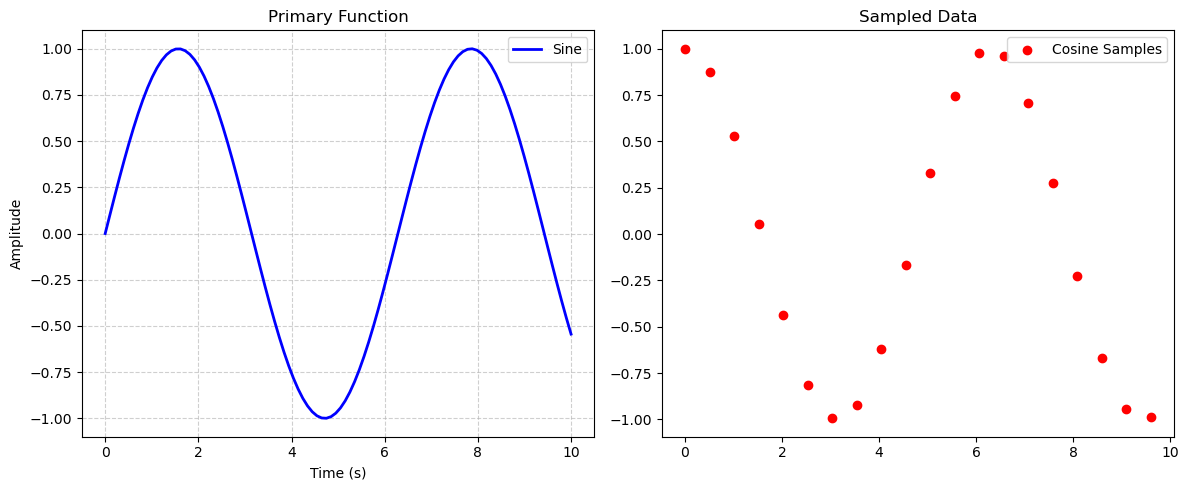

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# Create data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Standard line
ax1.plot(x, y1, color='blue', label='Sine', linewidth=2)
ax1.set_title("Primary Function")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Scatter / Data points
ax2.scatter(x[::5], y2[::5], color='red', marker='o', label='Cosine Samples')
ax2.set_title("Sampled Data")
ax2.legend()

plt.tight_layout() # Prevents labels from overlapping
plt.show()

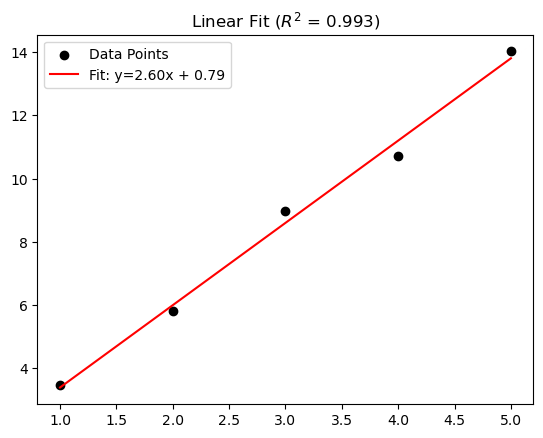

In [136]:
from scipy import stats

# Generate dummy data
x_data = np.array([1, 2, 3, 4, 5])
y_noisy = 2.5 * x_data + 1.2 + np.random.normal(0, 0.5, 5)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_noisy)
line = slope * x_data + intercept

plt.scatter(x_data, y_noisy, label='Data Points', color='black')
plt.plot(x_data, line, color='red', label=f'Fit: y={slope:.2f}x + {intercept:.2f}')
plt.title(f"Linear Fit ($R^2$ = {r_value**2:.3f})")
plt.legend()
plt.show()

In [ ]:
data = np.random.normal(loc=0, scale=1, size=1000) # Normal distribution

plt.hist(data, bins=30, color='skyblue', edgecolor='black', density=True)
plt.axvline(np.mean(data), color='red', linestyle='dashed', label='Mean')
plt.title("Frequency Distribution of Errors")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

In [ ]:
#linearizing data
#michaelis menten y=(ax) / (b+x)
#to linearize it, take reciprocal of both sides
#1/y = b/ax + x/ax
#plot 1/y vs 1/x, slope = b/a, intercept = 1/a/ 

#y=a/(ax+b)

#1/y = ax+b
#plot 1/y vs x. 


#y = ae^(bx)
#ln y = ln a  + Bx ln e. 
#plot x vs lny

#y = ax^b
#ln y = lna  + b * ln(x)
#plot lny vs ln x


error. 

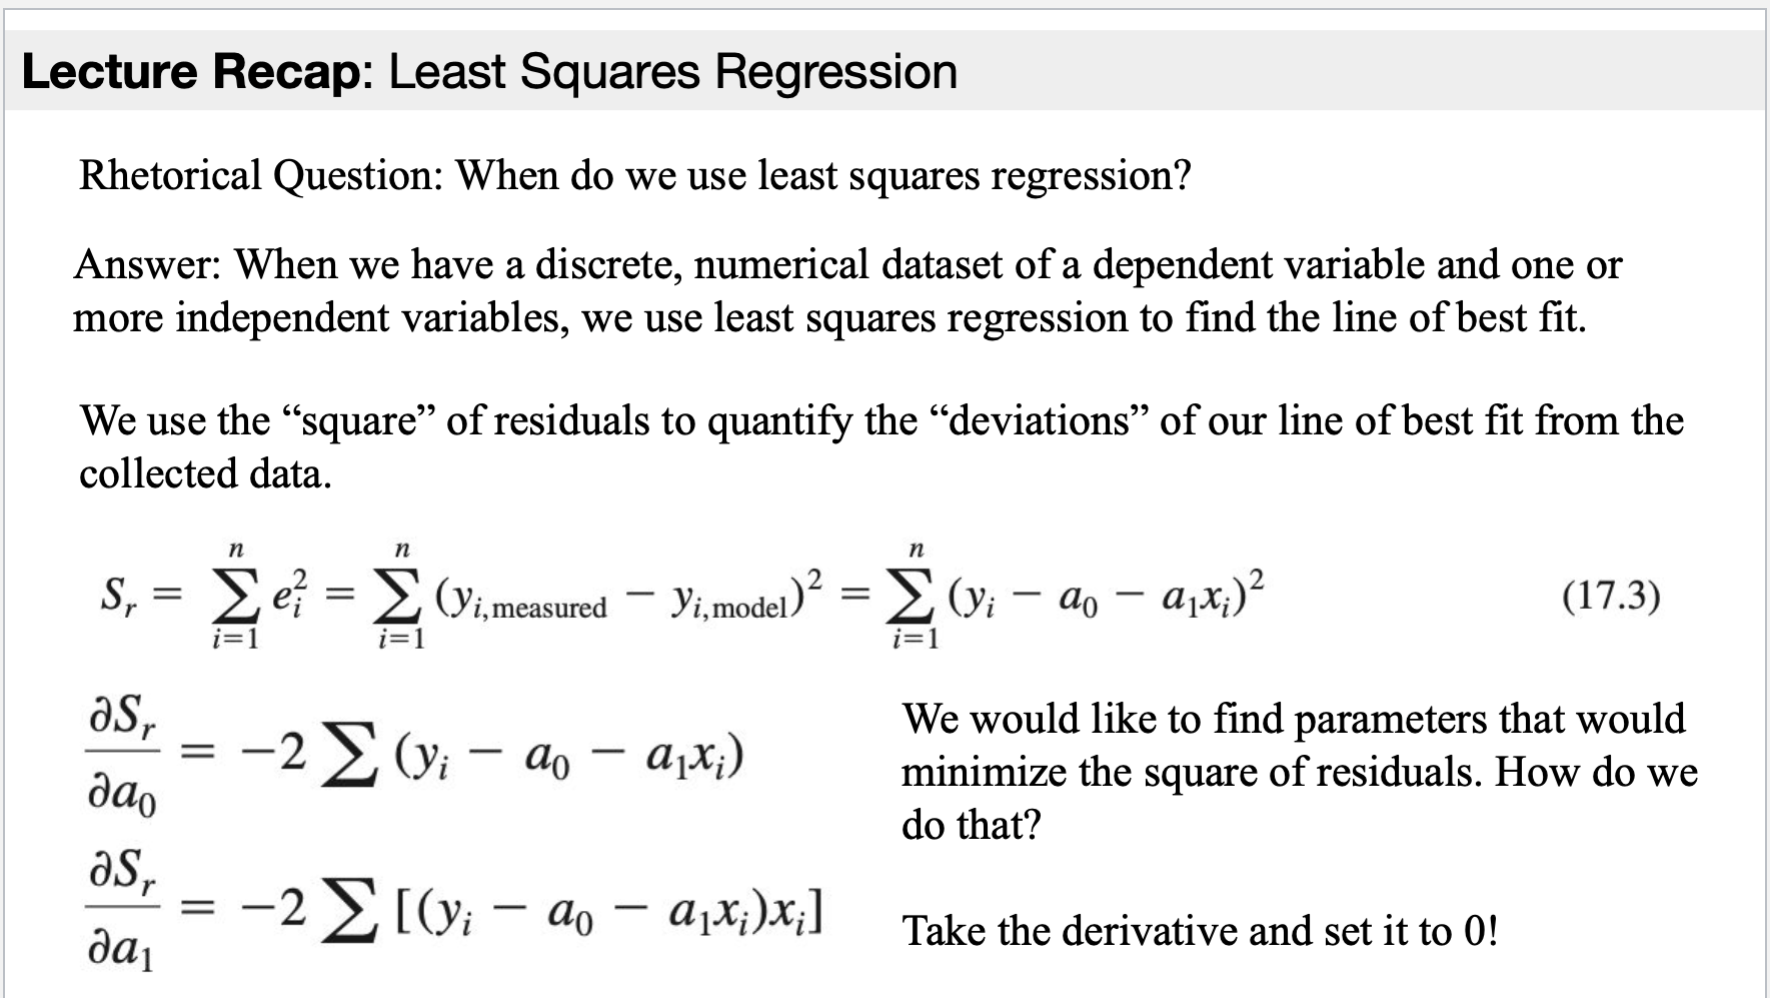
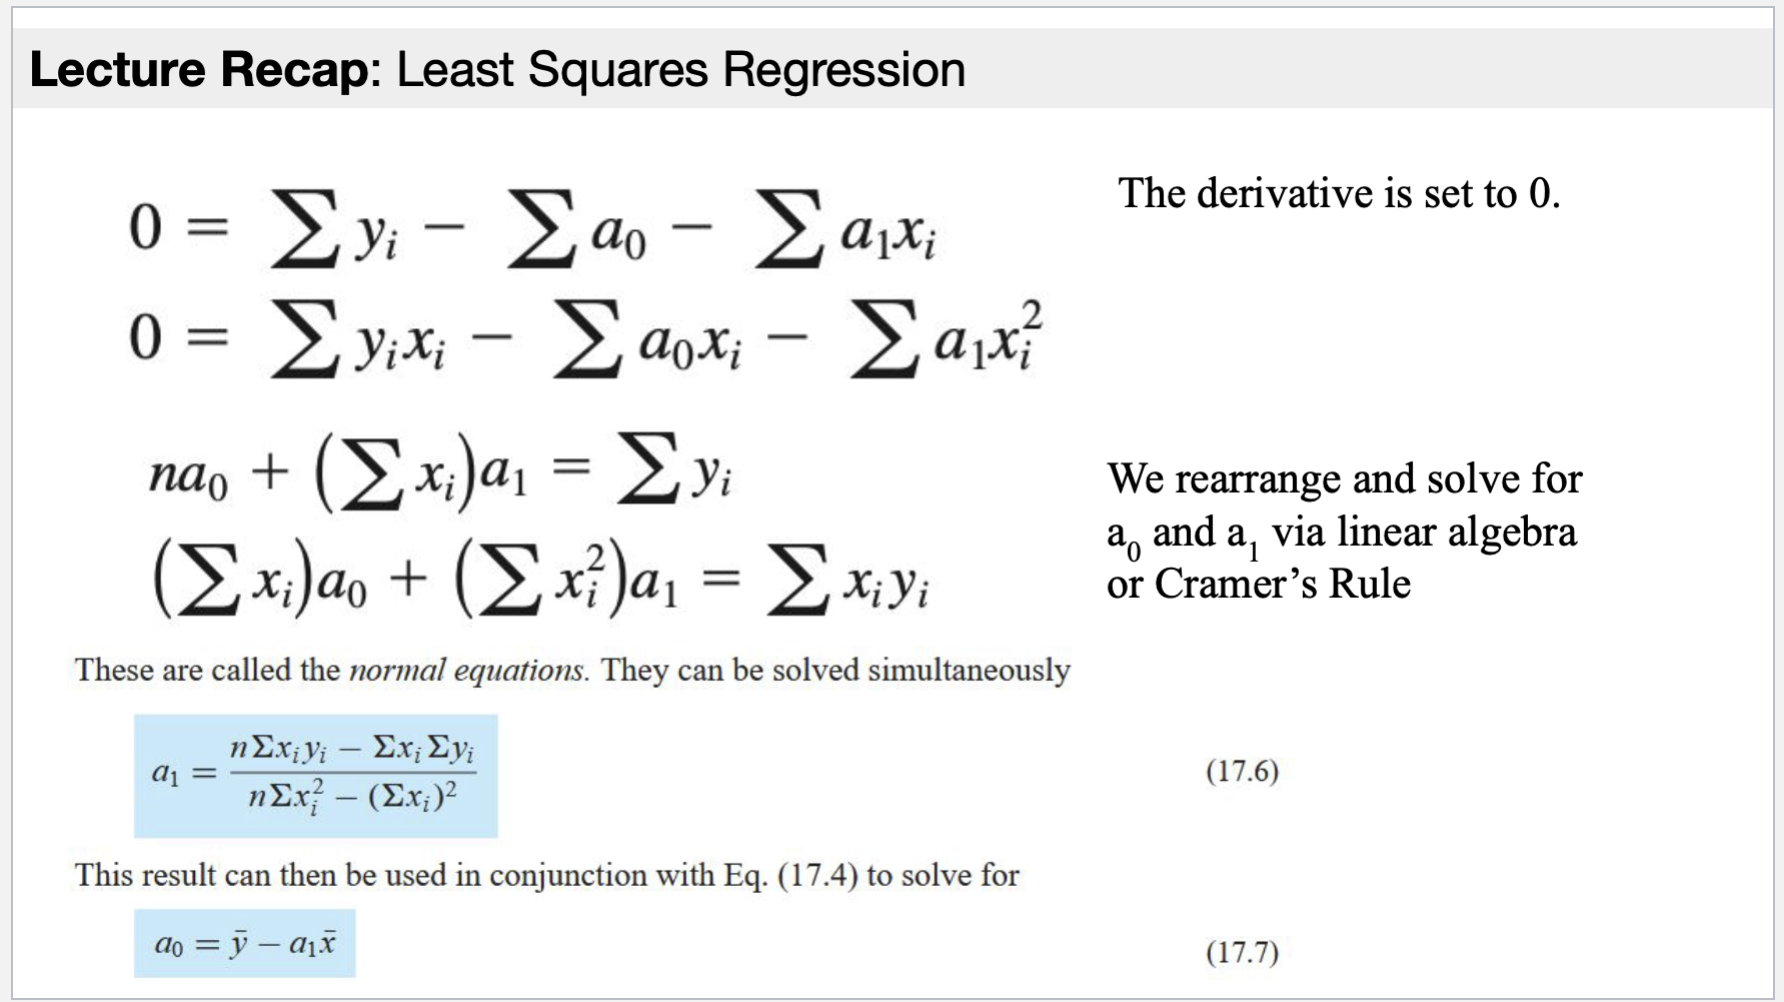
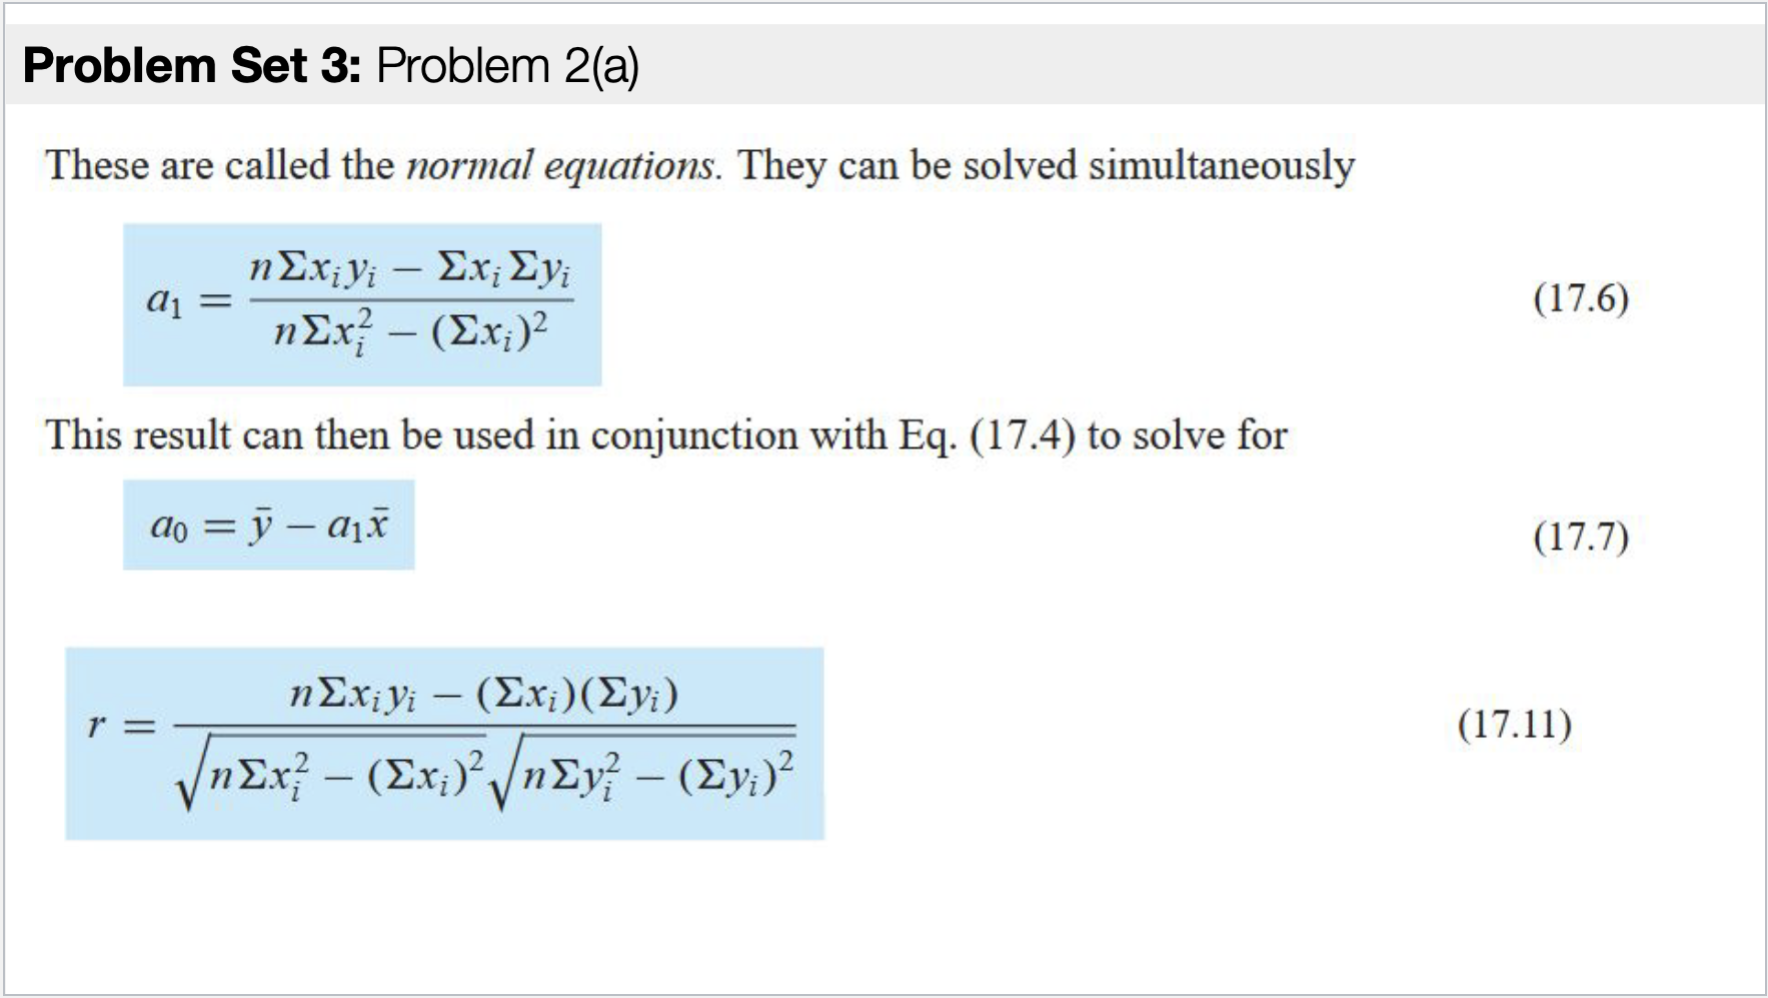

In [ ]:
import numpy as np

def polynomial_regression(x, y, m):
    """
    Fits an m-order polynomial to data points (x, y).
    Follows the logic from Figure 17.13.
    """
    n = len(x)
    
    # Step 3: Check if regression is possible
    if n < m + 1:
        raise ValueError(f"Regression impossible: n ({n}) must be >= m + 1 ({m + 1})")

    # Step 4: Compute elements of the normal equation (Augmented Matrix)
    # The matrix size is (m+1) rows by (m+2) columns
    aug_matrix = np.zeros((m + 1, m + 2))

    for i in range(1, m + 2):  # i from 1 to order + 1
        # Fill the coefficient part of the matrix (Symmetric)
        for j in range(1, i + 1):  # j from 1 to i
            k = i + j - 2
            sum_x = np.sum(np.power(x, k))
            
            # Map 1-based pseudocode to 0-based Python indexing
            aug_matrix[i-1, j-1] = sum_x
            aug_matrix[j-1, i-1] = sum_x
            
        # Fill the right-hand side vector (last column)
        sum_xy = np.sum(y * np.power(x, i - 1))
        aug_matrix[i-1, m + 1] = sum_xy

    # Step 5: Solve the augmented matrix for coefficients
    # Separate the A matrix and B vector from the augmented matrix
    A = aug_matrix[:, :-1]
    B = aug_matrix[:, -1]
    
    # Solve the system: A * a = B
    # This finds [a0, a1, ..., am]
    coefficients = np.linalg.solve(A, B)
    
    return coefficients

# --- Example Usage ---
# Data points (e.g., a simple quadratic trend)
x_data = np.array([0, 1, 2, 3, 4, 5])
y_data = np.array([2.1, 7.7, 13.6, 27.2, 40.9, 61.1])
order = 2  # We want to fit a 2nd order polynomial: y = a0 + a1*x + a2*x^2

try:
    coeffs = polynomial_regression(x_data, y_data, order)
    
    # Step 6: Print out the coefficients
    print(f"Polynomial Coefficients (a0 to a{order}):")
    for idx, val in enumerate(coeffs):
        print(f"a{idx}: {val:.4f}")

except ValueError as e:
    print(e)



import numpy as np

def multiple_linear_regression(X, y):
    """
    X: A 2D array where each column is a different variable (x1, x2, x3...)
    y: The target values
    """
    n_samples = X.shape[0]
    
    # Add a column of 1s to the start of X to represent the intercept (a0)
    # This turns X into the Design Matrix (Z)
    ones = np.ones((n_samples, 1))
    Z = np.hstack((ones, X))
    
    # Step 4 & 5 combined using the Normal Equation: a = (Z^T * Z)^-1 * Z^T * y
    # Z.T is the transpose (Z^T)
    # @ is the matrix multiplication operator in Python
    
    ZT_Z = Z.T @ Z
    ZT_y = Z.T @ y
    
    # Solve for coefficients [a0, a1, a2, ...]
    coefficients = np.linalg.solve(ZT_Z, ZT_y)
    
    return coefficients

# --- Example: Predicting House Price ---
# Features: [Sq_Footage, Num_Bedrooms, Age_of_House]
X_data = np.array([
    [1500, 3, 10],
    [2000, 4, 5],
    [1200, 2, 20],
    [2500, 4, 2]
])

y_prices = np.array([300000, 450000, 200000, 550000])

coeffs = multiple_linear_regression(X_data, y_prices)

print("MLR Coefficients:")
print(f"Intercept (a0): {coeffs[0]:.2f}")
print(f"Sq Footage (a1): {coeffs[1]:.2f}")
print(f"Bedrooms (a2): {coeffs[2]:.2f}")
print(f"Age (a3): {coeffs[3]:.2f}")

Polynomial Coefficients (a0 to a2):
a0: 2.4786
a1: 2.3593
a2: 1.8607


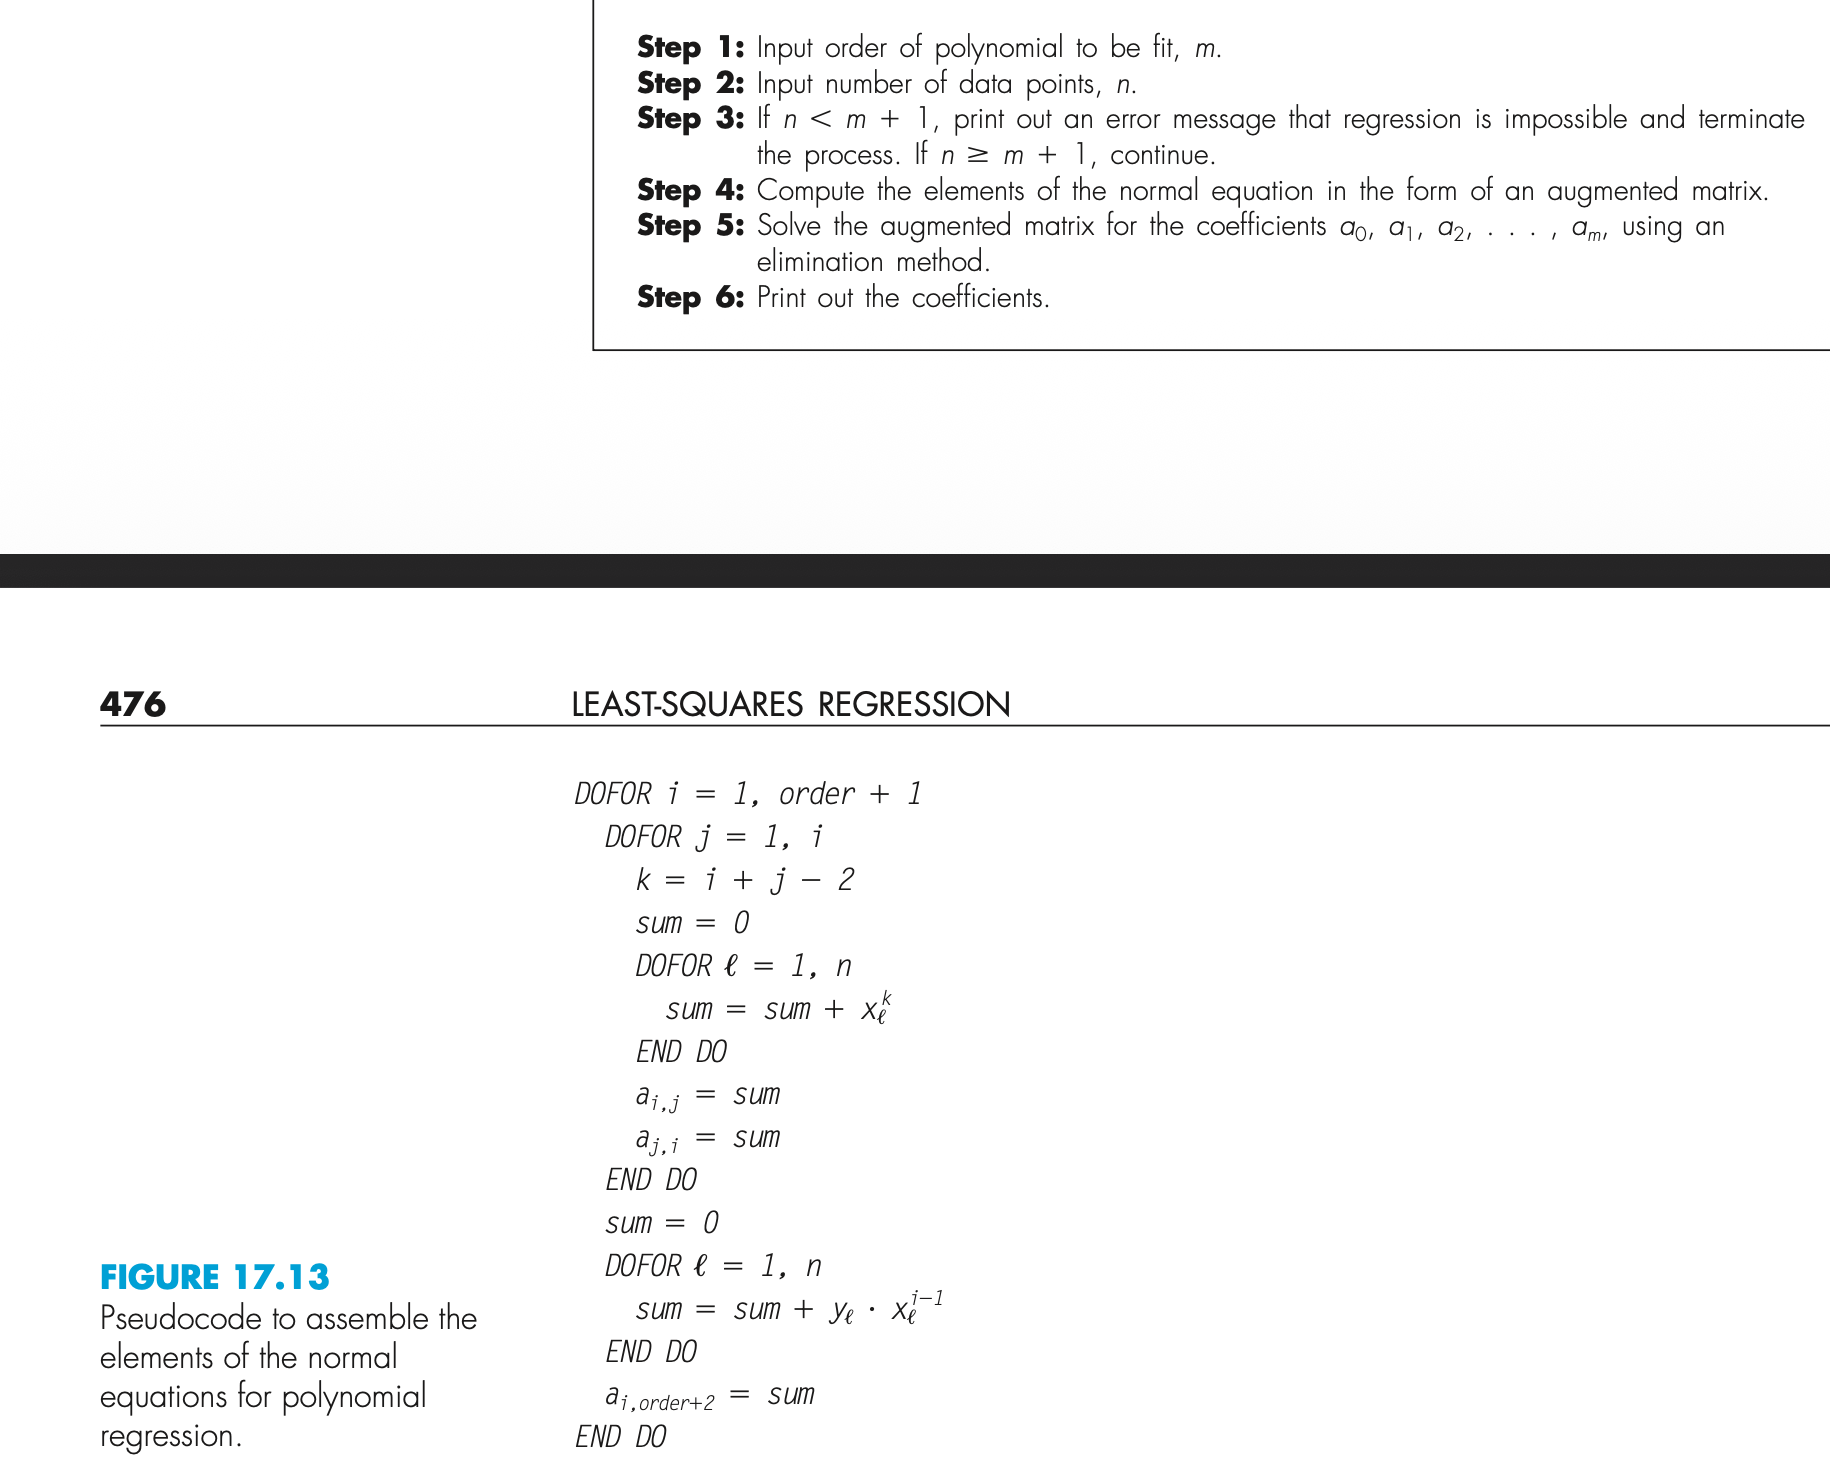

[3, 4, 5, 6, 7]
[1, 2]
[6, 7]
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5, 6, 7]
[2, 3]
[]


[]

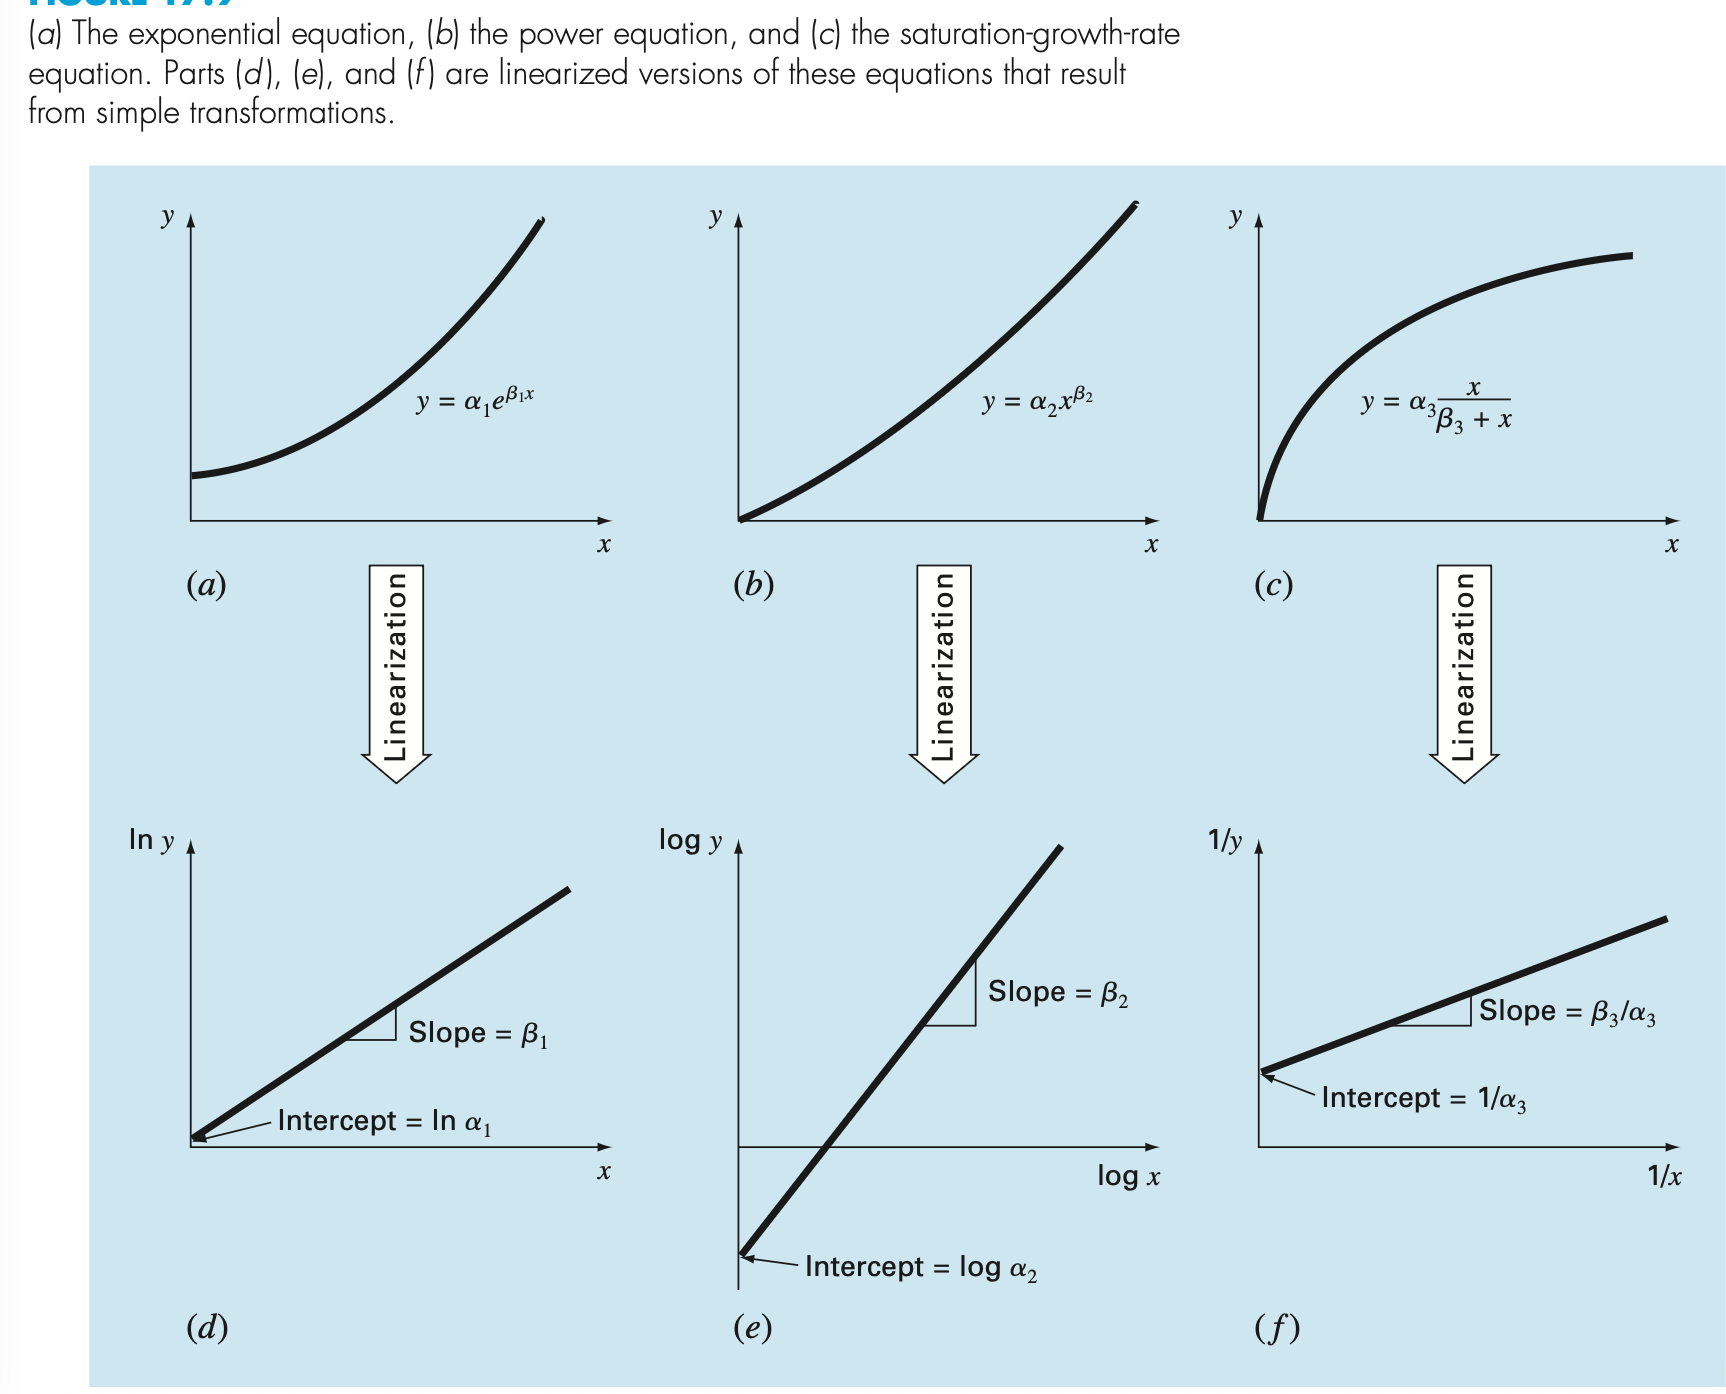

In [12]:
import numpy as np
from scipy import stats

# Data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.1, 3.9, 6.2, 8.1, 10.1])

# 1. Standard Deviation
std_dev = np.std(y)

# 2. Standard Error of the Mean
se_mean = stats.sem(y)

# 3. Standard Regression Error (and others)
slope, intercept, r_val, p_val, std_err_slope = stats.linregress(x, y)

# Calculation of Standard Error of Estimate manually:
y_pred = slope * x + intercept
residuals = y - y_pred
# Standard Error of Estimate (Sy/x)
std_err_estimate = np.sqrt(np.sum(residuals**2) / (len(y) - 2))

print(f"Typical 'miss' of the line: {std_err_estimate:.4f}")

Typical 'miss' of the line: 0.1211


In [2]:
#enumerate
fruits = ['apple', 'banana', 'cherry']

for index, value in enumerate(fruits):
    print(f"Index: {index}, Fruit: {value}")


guesses = [2.1, 2.5, 2.9, 3.0]

for i, x in enumerate(guesses):
    if i > 0:
        error = abs(x - guesses[i-1])
        print(f"Iteration {i}: x = {x}, Error = {error}")

Index: 0, Fruit: apple
Index: 1, Fruit: banana
Index: 2, Fruit: cherry
Iteration 1: x = 2.5, Error = 0.3999999999999999
Iteration 2: x = 2.9, Error = 0.3999999999999999
Iteration 3: x = 3.0, Error = 0.10000000000000009


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_error_analysis(approx_list, true_value=None, log_scale=True):
    """
    Calculates and plots True and/or Approximate Relative Error.
    approx_list: List/Array of values from your iterations.
    true_value: (Optional) The exact root if known.
    log_scale: Boolean. Log scales are better for seeing error convergence.
    """
    iterations = np.arange(len(approx_list))
    
    # 1. Calculate Approximate Relative Error (ea)
    ea = []
    for i in range(len(approx_list)):
        if i == 0:
            ea.append(np.nan) # No previous value for the first guess
        else:
            current = approx_list[i]
            previous = approx_list[i-1]
            # Formula from
            error = abs((current - previous) / current) * 100
            ea.append(error)
    
    # 2. Calculate True Relative Error (et) if true_value is provided
    et = None
    if true_value is not None:
        et = [abs((true_value - x) / true_value) * 100 for x in approx_list]

    # 3. Plotting
    plt.plot(iterations[1:], ea[1:], label='Approximate Relative Error ($\epsilon_a$)', marker='o')
    
    if et is not None:
        plt.plot(iterations, et, label='True Relative Error ($\epsilon_t$)', linestyle='--', marker='s')
    
    if log_scale:
        plt.yscale('log')
        plt.ylabel("Relative Error (%) - Log Scale")
    else:
        plt.ylabel("Relative Error (%)")
        
    plt.xlabel("Iteration Number")
    plt.title("Error Convergence Analysis")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

    return np.array(ea), (np.array(et) if et else None)

<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_1642/704464396.py:31: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(iterations[1:], ea[1:], label='Approximate Relative Error ($\epsilon_a$)', marker='o')
/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_1642/704464396.py:34: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(iterations, et, label='True Relative Error ($\epsilon_t$)', linestyle='--', marker='s')


In [ ]:
# Derivative,Method,Low Order (Et​),High Order (Et​)
# 1st (f′),Forward,O(h),O(h2)
# 1st (f′),Backward,O(h),O(h2)
# 1st (f′),Central,O(h2),O(h4)
# 2nd (f′′),Forward,O(h),O(h2)
# 2nd (f′′),Backward,O(h),O(h2)
# 2nd (f′′),Central,O(h2),O(h4)